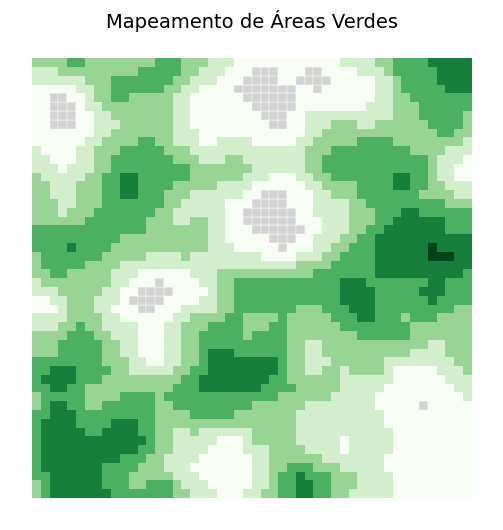

In [12]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from noise import pnoise2

# =====================================================================
# 1. Carregamento do Shapefile
# =====================================================================
# gdf = gpd.read_file("caminho/para/seu_arquivo.shp")

def generate_dummy_polygons(xmin, xmax, ymin, ymax, size):
    """Gera polígonos regulares apenas para demonstrar."""
    polys = []
    for x in np.arange(xmin, xmax, size):
        for y in np.arange(ymin, ymax, size):
            polys.append(Polygon([(x, y), (x+size, y), (x+size, y+size), (x, y+size)]))
    return gpd.GeoDataFrame(geometry=polys)

gdf = generate_dummy_polygons(0, 10, 0, 10, 0.2)
# ----------------------------------------------------------------

# =====================================================================
# 2. Função de risco de alagamento (Perlin Noise)
# =====================================================================
def risk_func(x, y, precipitacao=1.0):
    scale_terreno = 3.5
    
    # Gera um ruído que simula o relevo da região (partes altas e baixas)
    perlin_val = pnoise2(x/scale_terreno, y/scale_terreno, octaves=3, persistence=0.5, lacunarity=2.0, base=99)
    
    # Normaliza o valor para ficar entre ~0 e 1
    terreno_norm = (perlin_val + 1) / 2
    
    # Áreas de baixada (maior acúmulo) invertendo o ruído
    acumulo = 1.0 - terreno_norm 
    
    # Aplica o nível do evento de chuva
    risco_final = acumulo * precipitacao
    
    # Limiares de alagamento (zera o risco em áreas mais secas/altas)
    if risco_final < 0.4:
        return 0.0
    return np.clip((risco_final - 0.4) * 2, 0, 1)

nivel_areas_verdes = 1.2

# =====================================================================
# 3. Aplicação nos polígonos
# =====================================================================
# Usa os centroides para calcular o valor em cada polígono do SHP
gdf["cx"] = gdf.geometry.centroid.x
gdf["cy"] = gdf.geometry.centroid.y
gdf["areas_verdes"] = gdf.apply(lambda r: risk_func(r.cx, r.cy, precipitacao=nivel_areas_verdes), axis=1)

# =====================================================================
# 4. Plotagem e Exportação da Imagem
# =====================================================================
px_width = 820
px_height = 540
dpi = 100

fig, ax = plt.subplots(figsize=(px_width / dpi, px_height / dpi), dpi=dpi)

# Plota a base dos polígonos vazios em cinza para representar a cidade
gdf.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3)

# Filtra e plota apenas as áreas que sofrem algum alagamento com gradiente azul
gdf_flooded = gdf[gdf["areas_verdes"] > 0]

if not gdf_flooded.empty:
    cmap = plt.get_cmap("Greens", 6)
    gdf_flooded.plot(column="areas_verdes", ax=ax, cmap=cmap, legend=False, vmin=0, vmax=1)

ax.set_axis_off()
ax.set_title(f"Mapeamento de Áreas Verdes", fontsize=14)

plt.tight_layout()
plt.savefig(f"shp_areas_verdes_{nivel_areas_verdes}.jpg", dpi=dpi, bbox_inches="tight")

plt.show()

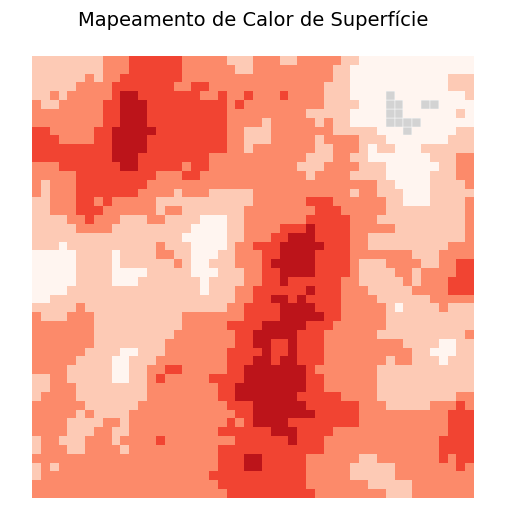

In [13]:


gdf = generate_dummy_polygons(0, 10, 0, 10, 0.2)

nivel_calor = 1.2


def heat_risk_func(x, y, precipitacao=1.0):
    scale_terreno = 3.5
    
    # Gera um ruído que simula o relevo da região (partes altas e baixas)
    perlin_val = pnoise2(x/scale_terreno, y/scale_terreno, octaves=12, persistence=0.5, lacunarity=2.0, base=42)
    
    # Normaliza o valor para ficar entre ~0 e 1
    terreno_norm = (perlin_val + 1) / 2
    
    # Áreas de baixada (maior acúmulo) invertendo o ruído
    acumulo = 1.0 - terreno_norm 
    
    # Aplica o nível do evento de chuva
    risco_final = acumulo * precipitacao
    
    # Limiares de alagamento (zera o risco em áreas mais secas/altas)
    if risco_final < 0.4:
        return 0.0
    return np.clip((risco_final - 0.4) * 2, 0, 1)

gdf["cx"] = gdf.geometry.centroid.x
gdf["cy"] = gdf.geometry.centroid.y
gdf["risco_calor"] = gdf.apply(lambda r: heat_risk_func(r.cx, r.cy, precipitacao=nivel_calor), axis=1)


px_width = 820
px_height = 540
dpi = 100

fig, ax = plt.subplots(figsize=(px_width / dpi, px_height / dpi), dpi=dpi)

# Plota a base dos polígonos vazios em cinza para representar a cidade
gdf.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3)

# Filtra e plota apenas as áreas que sofrem algum calor com gradiente azul
gdf_heat = gdf[gdf["risco_calor"] > 0]

if not gdf_heat.empty:
    cmap = plt.get_cmap("Reds", 6)
    gdf_heat.plot(column="risco_calor", ax=ax, cmap=cmap, legend=False, vmin=0, vmax=1)

ax.set_axis_off()
ax.set_title(f"Mapeamento de Calor de Superfície", fontsize=14)

plt.tight_layout()
plt.savefig(f"shp_risco_calor_{nivel_calor}.jpg", dpi=dpi, bbox_inches="tight")

plt.show()